# Coding Task: Overfitting with Polynomial Regression

**Goal:** Visualize underfitting, just‑right fitting, and overfitting in action.

## What You Will Do

1. Generate 20 random points from the true function:  
   `y = sin(2πx) + ε` with Gaussian noise `ε ~ N(0, 0.3²)`.
2. For polynomial degrees `d = [1, 2, 3, 5, 10, 15]`:
   - Fit a polynomial of degree `d` to the training data.
   - Compute training error (Mean Squared Error on the 20 points).
   - Compute test error (MSE on 200 fresh points from the same true function).
   - Plot the fitted polynomial curve over the data.
3. Create **three plots side by side**:
   - **Left:** Underfitting (d = 1 or 2) – high error on both.
   - **Middle:** Just right (d = 3 or 4) – low error on both.
   - **Right:** Overfitting (d = 10 or 15) – training error near zero, test error high.
4. Answer the questions (see end of notebook).

**Deliverable:** Submit this notebook with all cells executed and your answers.

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Set random seed for reproducibility
np.random.seed(42)

def generate_data(n_points, noise_std=0.3, x_range=(0, 1)):
    """
    Generate points from y = sin(2πx) + Gaussian noise.
    Returns: x (sorted), y (with noise)
    """
    x = np.random.uniform(x_range[0], x_range[1], n_points)
    x_sorted = np.sort(x)
    y = np.sin(2 * np.pi * x_sorted) + np.random.normal(0, noise_std, n_points)
    return x_sorted, y

# Generate training data (20 points)
x_train, y_train = generate_data(20)

# Generate test data (200 points, with noise)
x_test, y_test = generate_data(200)

# For plotting the true function (no noise)
x_true = np.linspace(0, 1, 1000)
y_true = np.sin(2 * np.pi * x_true)

print(f"Training set size: {len(x_train)}")
print(f"Test set size: {len(x_test)}")

Training set size: 20
Test set size: 200


In [13]:
def fit_polynomial(degree, x_train, y_train, x_test, y_test):
    """
    Fit a polynomial of given degree to the training data.
    Returns:
        train_error (MSE), test_error (MSE),
        x_plot (for smooth curve), y_plot_pred (fitted values on x_plot)
    """
    # Create polynomial features
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    
    # Transform training inputs (x_train) to polynomial features
    X_train_poly = poly.fit_transform(x_train.reshape(-1, 1))
    
    # Transform test inputs similarly
    X_test_poly = poly.transform(x_test.reshape(-1, 1))
    
    # Create and train a LinearRegression model
    model = LinearRegression()
    model.fit(X_train_poly, y_train)
    
    # Predict on training and test sets, compute MSE
    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)
    train_error = mean_squared_error(y_train, y_train_pred)
    test_error = mean_squared_error(y_test, y_test_pred)
    
    # For smooth plotting: create 500 points between 0 and 1
    x_plot = np.linspace(0, 1, 500)
    X_plot_poly = poly.transform(x_plot.reshape(-1, 1))
    y_plot_pred = model.predict(X_plot_poly)
    
    return train_error, test_error, x_plot, y_plot_pred

In [15]:
degrees = [1, 2, 3, 5, 10, 15]
results = []

for d in degrees:
    train_err, test_err, x_plot, y_plot = fit_polynomial(d, x_train, y_train, x_test, y_test)
    results.append((d, train_err, test_err, x_plot, y_plot))

# Print summary table
print("Degree | Train MSE | Test MSE")
print("-----------------------------")
for d, tr_err, te_err, _, _ in results:
    print(f"{d:6d} | {tr_err:.6f} | {te_err:.6f}")

Degree | Train MSE | Test MSE
-----------------------------
     1 | 0.234291 | 0.274570
     2 | 0.234098 | 0.273889
     3 | 0.067278 | 0.094327
     5 | 0.065369 | 0.093668
    10 | 0.036424 | 0.231498
    15 | 0.008189 | 8.034266


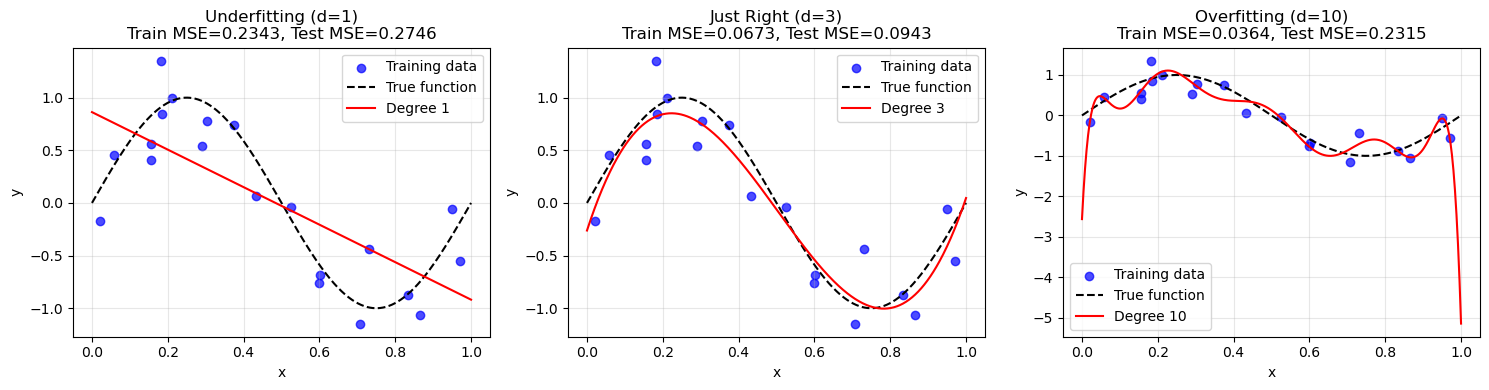

In [17]:
# Choose specific degrees for the three plots
underfit_deg = 1
justright_deg = 3
overfit_deg = 10

def get_result_by_degree(degree, results):
    for d, tr, te, xp, yp in results:
        if d == degree:
            return tr, te, xp, yp
    return None, None, None, None

_, _, x_plot_under, y_plot_under = get_result_by_degree(underfit_deg, results)
_, _, x_plot_right, y_plot_right = get_result_by_degree(justright_deg, results)
_, _, x_plot_over, y_plot_over = get_result_by_degree(overfit_deg, results)

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Underfitting plot
axes[0].scatter(x_train, y_train, c='blue', alpha=0.7, label='Training data')
axes[0].plot(x_true, y_true, 'k--', label='True function')
axes[0].plot(x_plot_under, y_plot_under, 'r-', label=f'Degree {underfit_deg}')
axes[0].set_title(f'Underfitting (d={underfit_deg})\nTrain MSE={results[0][1]:.4f}, Test MSE={results[0][2]:.4f}')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Just right plot
axes[1].scatter(x_train, y_train, c='blue', alpha=0.7, label='Training data')
axes[1].plot(x_true, y_true, 'k--', label='True function')
axes[1].plot(x_plot_right, y_plot_right, 'r-', label=f'Degree {justright_deg}')
axes[1].set_title(f'Just Right (d={justright_deg})\nTrain MSE={results[2][1]:.4f}, Test MSE={results[2][2]:.4f}')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Overfitting plot
axes[2].scatter(x_train, y_train, c='blue', alpha=0.7, label='Training data')
axes[2].plot(x_true, y_true, 'k--', label='True function')
axes[2].plot(x_plot_over, y_plot_over, 'r-', label=f'Degree {overfit_deg}')
axes[2].set_title(f'Overfitting (d={overfit_deg})\nTrain MSE={results[4][1]:.4f}, Test MSE={results[4][2]:.4f}')
axes[2].set_xlabel('x')
axes[2].set_ylabel('y')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

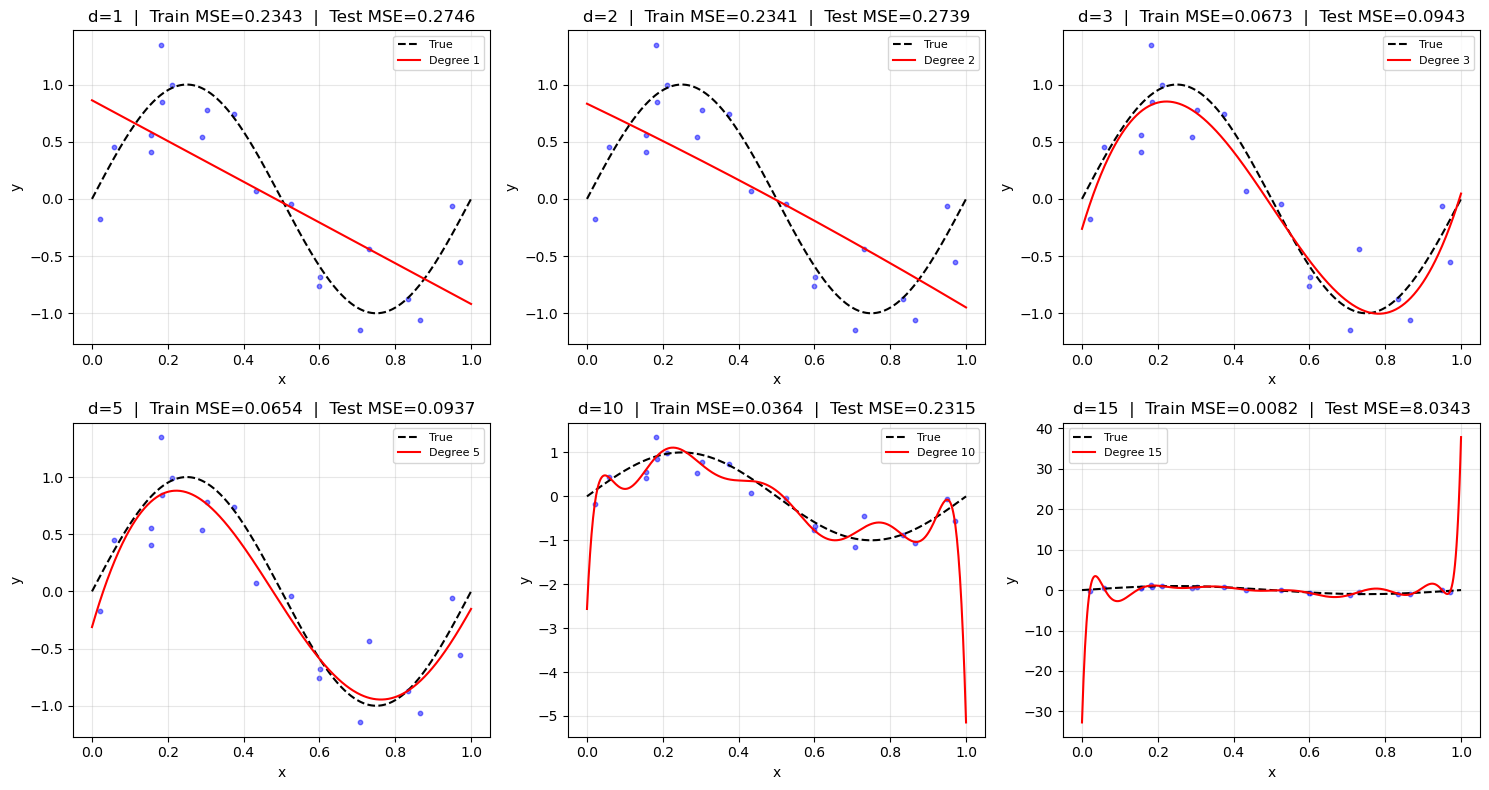

In [9]:
# Plot all degrees in a 2x3 grid
n_degrees = len(degrees)
rows = (n_degrees + 2) // 3
fig, axes = plt.subplots(rows, 3, figsize=(15, 4*rows))
axes = axes.flatten()

for idx, (d, tr_err, te_err, x_plot, y_plot) in enumerate(results):
    axes[idx].scatter(x_train, y_train, c='blue', alpha=0.5, s=10)
    axes[idx].plot(x_true, y_true, 'k--', label='True')
    axes[idx].plot(x_plot, y_plot, 'r-', label=f'Degree {d}')
    axes[idx].set_title(f'd={d}  |  Train MSE={tr_err:.4f}  |  Test MSE={te_err:.4f}')
    axes[idx].set_xlabel('x')
    axes[idx].set_ylabel('y')
    axes[idx].legend(fontsize=8)
    axes[idx].grid(True, alpha=0.3)

# Hide any unused subplots
for i in range(len(degrees), len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

## Questions to Answer

Run all cells above, then answer the following questions (write your answers here):

1. **At what degree does overfitting start? Why?**  
   (Look at the table of errors and the plots.)

2. **Why does a very high degree (e.g., 15) give nearly zero training error but high test error?**  
   Explain in terms of bias and variance.

3. **If you had more training points (e.g., 200 instead of 20), would overfitting start at a higher or lower degree? Why?**

4. **What happens if you increase the noise level (e.g., σ = 0.5)? How would the optimal degree change?**

**Your answers:**  
[Type here]